# Credit Card Fraud Detection
- Dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
- Models:
    1. Logistic Regression
    2. XGBoost
    3. Decision Tree
    4. Random Forest
    5. KNN
    6. Naive Bayes

All models are wrapped in a single, shared `Pipeline` (scaling + model), so every model is trained and evaluated on identical, consistently preprocessed data.

## Problem Definition
Goal: build a model that reliably catches fraudulent transactions despite them being extremely rare, without generating excessive false alarms. Accuracy is not a meaningful metric here, since a model predicting "Not Fraud" for every transaction would score ~99.8% accuracy while catching zero fraud.

In [25]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, fbeta_score, precision_recall_curve, f1_score
)
from imblearn.over_sampling import SMOTE, ADASYN

## Data Collection

In [3]:
#Load Dataset
df = pd.read_csv('creditcard.csv')

In [4]:
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.shape

(284807, 31)

In [6]:
print("Class distribution:")
print(df['Class'].value_counts())

print("\nTotal missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df['Class'].value_counts(normalize=True) * 100

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Total missing values: 0
Duplicate rows: 1081


Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

There is class imbalance:
- 0 - Not Fraud
- 1 - Fraud

In [7]:
#separating for data analysis only (not used for modeling)
notFraud = df[df.Class == 0]
fraud = df[df.Class == 1]

In [8]:
notFraud.Amount.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [9]:
fraud.Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

## Preprocessing

In [10]:
# Duplicates are deliberately NOT dropped: a portion of them are fraud cases,
# and removing them would shrink an already very small minority class.
# df = df.drop_duplicates()  # left here for reference, intentionally not applied

print("Shape:", df.shape)
print("\nClass distribution:")
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

Shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


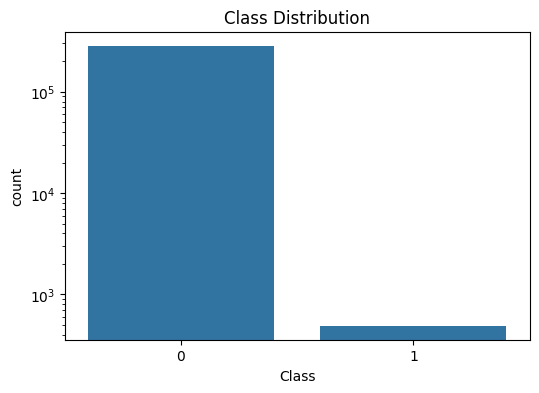

In [11]:
#Class distribution plot
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Class')
plt.title('Class Distribution')
plt.yscale('log')  # log scale needed - fraud bar would be invisible otherwise
plt.show()

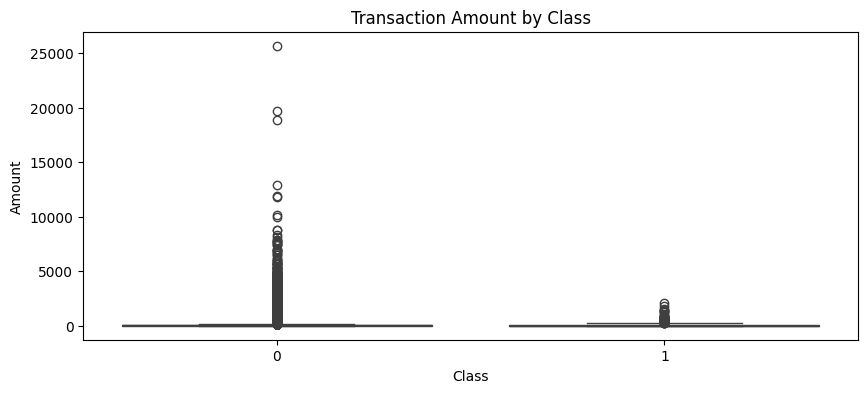

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [12]:
#Amount distribution: fraud vs not fraud
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='Class', y='Amount')
plt.title('Transaction Amount by Class')
plt.show()

print(df.groupby('Class')['Amount'].describe())

### Correlation

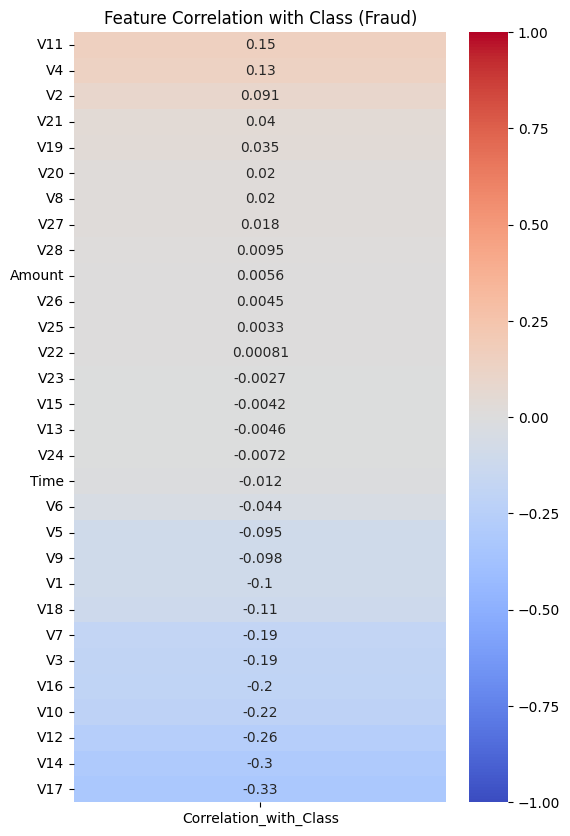

In [13]:
# Correlation with Class
corr = df.drop(columns=['Class']).corrwith(df['Class']).to_frame('Correlation_with_Class')
corr = corr.sort_values(by='Correlation_with_Class', ascending=False)

plt.figure(figsize=(6, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation with Class (Fraud)')
plt.show()

### Train-Test Split

In [14]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

Feature Matrix Shape: (284807, 30)
Target Vector Shape: (284807,)


In [15]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,   # test = 20% of full data
    random_state=42,
    stratify=y
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp,
    test_size=0.25,   # valid = 25% of the remaining 80% = 20% of full data
    stratify=y_temp,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_valid.shape)
print("Testing set:", X_test.shape)

Training set: (170883, 30)
Validation set: (56962, 30)
Testing set: (56962, 30)


### Feature Scaling

In [16]:
# Time and Amount are scaled with RobustScaler (less sensitive to outliers than StandardScaler,
# useful here since Amount has extreme outlier transactions).
# V1-V28 are already PCA components and are passed through unchanged.
# Every model below is wrapped in a Pipeline using this SAME preprocessor,
# so all models train and evaluate on identical, consistently scaled data.

numeric_features = ["Time", "Amount"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), numeric_features)
    ],
    remainder="passthrough"
)

# Column order after this transform: Time, Amount, then V1..V28 (passthrough order)
feature_names_after_preprocessing = numeric_features + [c for c in X_train.columns if c not in numeric_features]
print(feature_names_after_preprocessing)

['Time', 'Amount', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']


### Undersampling (training data only)
Built here once, up front, so it is available to every model that wants to test undersampling.

In [17]:
train_df = pd.concat([X_train, y_train], axis=1)

notFraud_train = train_df[train_df.Class == 0]
fraud_train = train_df[train_df.Class == 1]

notFraud_undersampled = notFraud_train.sample(n=len(fraud_train), random_state=42)

balanced_df = pd.concat([fraud_train, notFraud_undersampled])
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

X_train_balanced = balanced_df.drop(columns="Class")
y_train_balanced = balanced_df["Class"]

print("Balanced training class distribution:")
print(y_train_balanced.value_counts())

Balanced training class distribution:
Class
0    295
1    295
Name: count, dtype: int64


## Model Training

### Logistic Regression

Using class_weight parameter: https://www.geeksforgeeks.org/machine-learning/how-does-the-classweight-parameter-in-scikit-learn-work/

Accuracy: 0.9984551104244935

Classification Report:
               precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.53      0.88      0.66        98

    accuracy                           1.00     56962
   macro avg       0.77      0.94      0.83     56962
weighted avg       1.00      1.00      1.00     56962



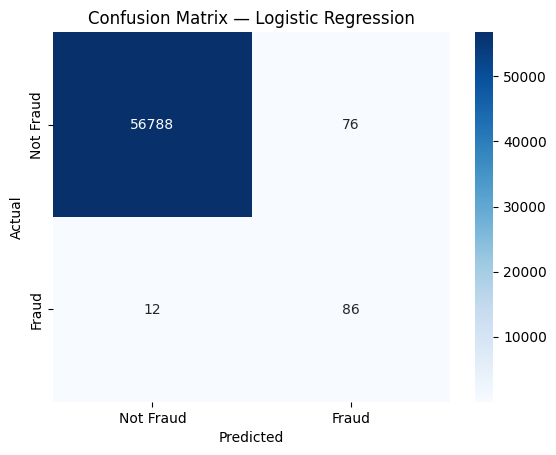

In [18]:
log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        solver='lbfgs', max_iter=200,
        class_weight={0: 1, 1: 30}  # gentler than 'balanced'
    )),
])

log_reg_pipeline.fit(X_train, y_train)

y_pred_lr = log_reg_pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr, target_names=['Not Fraud', 'Fraud'], zero_division=0))

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix — Logistic Regression')
plt.show()

### SMOTE (training data only)
Reference: https://www.geeksforgeeks.org/machine-learning/smote-for-imbalanced-classification-with-python/

After SMOTE
Class
0    170588
1    170588
Name: count, dtype: int64
Class
0    50.0
1    50.0
Name: proportion, dtype: float64


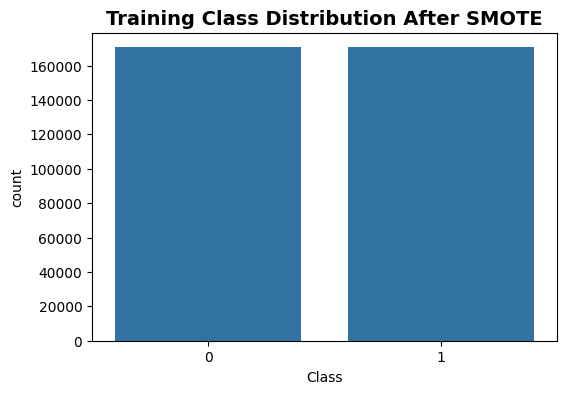

In [19]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE")
print(y_train_sm.value_counts())
print(y_train_sm.value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(x=y_train_sm)
plt.title("Training Class Distribution After SMOTE", fontsize=14, fontweight="bold")
plt.show()

### XGBoost
Reference: https://www.geeksforgeeks.org/machine-learning/xgboost/

In [20]:
# Train XGBoost on the training set (X_train, y_train) and evaluate on the test set (X_test, y_test).
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum() #handle class imbalance

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=150,        # reduced from 400
        max_depth=3,             # reduced from 4
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,      # increased from 2 — requires more samples per split
        reg_alpha=10,            # increased from 0.5 — back to your original, non-overfit value
        reg_lambda=2.0,          # increased from 1.0
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )),
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)
y_probs_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("XGBoost on Test (default threshold):")

f2_default = fbeta_score(y_test, y_pred_xgb, beta=2, pos_label=1, zero_division=0)
print(f"F2-score (Fraud, default threshold): {f2_default:.4f}")

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, target_names=['Not Fraud', 'Fraud'], zero_division=0))

XGBoost on Test (default threshold):
F2-score (Fraud, default threshold): 0.4828
Accuracy: 0.9923984410659739
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      1.00     56864
       Fraud       0.17      0.89      0.29        98

    accuracy                           0.99     56962
   macro avg       0.59      0.94      0.64     56962
weighted avg       1.00      0.99      0.99     56962



In [21]:
# --- Validation-based threshold tuning ---
# Note: X_train here is already the final training set (validation was split off separately),
# so no separate sub-training split is needed — just reuse xgb_pipeline's probabilities on X_valid.
val_probs_xgb = xgb_pipeline.predict_proba(X_valid)[:, 1]

thresholds = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.6, 0.7, 0.8, 0.9]
results = []
for t in thresholds:
    y_pred_t = (val_probs_xgb >= t).astype(int)
    results.append({
        'threshold': t,
        'precision': precision_score(y_valid, y_pred_t, zero_division=0),
        'recall': recall_score(y_valid, y_pred_t, zero_division=0),
        'f2': fbeta_score(y_valid, y_pred_t, beta=2, zero_division=0),
    })

xgb_threshold_results = pd.DataFrame(results).sort_values('f2', ascending=False)
print("\nValidation threshold search:")
print(xgb_threshold_results)

xgb_best_threshold = float(xgb_threshold_results.iloc[0]['threshold'])
print(f"\nBest validation threshold (XGBoost): {xgb_best_threshold:.2f}")

xgb_test_pred = (y_probs_xgb >= xgb_best_threshold).astype(int)

print("\nXGBoost test results with validation-selected threshold:")
print(classification_report(y_test, xgb_test_pred, target_names=['Not Fraud', 'Fraud'], zero_division=0))

f2_tuned = fbeta_score(y_test, xgb_test_pred, beta=2, pos_label=1, zero_division=0)
print(f"F2-score (Fraud, tuned threshold): {f2_tuned:.4f}")


Validation threshold search:
   threshold  precision    recall        f2
9       0.90   0.624000  0.787879  0.748560
8       0.80   0.443243  0.828283  0.705680
7       0.70   0.310861  0.838384  0.625943
6       0.60   0.237822  0.838384  0.557047
5       0.50   0.174274  0.848485  0.478360
4       0.40   0.123547  0.858586  0.392066
3       0.30   0.082075  0.878788  0.298764
2       0.20   0.053724  0.888889  0.216323
1       0.10   0.030263  0.929293  0.133877
0       0.05   0.016367  0.929293  0.076450

Best validation threshold (XGBoost): 0.90

XGBoost test results with validation-selected threshold:
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.62      0.85      0.72        98

    accuracy                           1.00     56962
   macro avg       0.81      0.92      0.86     56962
weighted avg       1.00      1.00      1.00     56962

F2-score (Fraud, tuned threshold): 0.7890


Check for overfitting: compare train vs. test performance for the tuned XGBoost pipeline.

In [22]:
xgb_train_probs = xgb_pipeline.predict_proba(X_train)[:, 1]

# Apply the exact same custom threshold you used for the test set
xgb_train_pred_optimized = (xgb_train_probs >= xgb_best_threshold).astype(int)

print(f"\nXGBoost — Test Results (Threshold = {xgb_best_threshold:.2f}):")
print(classification_report(y_test, xgb_test_pred, target_names=['Not Fraud', 'Fraud'], zero_division=0))
f2_test = fbeta_score(y_test, xgb_test_pred, beta=2, pos_label=1, zero_division=0)
print(f"F2-score (Fraud, Test): {f2_test:.4f}")

print(f"\nXGBoost — Train Results (Threshold = {xgb_best_threshold:.2f}):")
print(classification_report(y_train, xgb_train_pred_optimized, target_names=['Not Fraud', 'Fraud'], zero_division=0))
f2_train = fbeta_score(y_train, xgb_train_pred_optimized, beta=2, pos_label=1, zero_division=0)
print(f"F2-score (Fraud, Train): {f2_train:.4f}")

print(f"\nF2 gap (Train - Test): {f2_train - f2_test:.4f}")


XGBoost — Test Results (Threshold = 0.90):
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.62      0.85      0.72        98

    accuracy                           1.00     56962
   macro avg       0.81      0.92      0.86     56962
weighted avg       1.00      1.00      1.00     56962

F2-score (Fraud, Test): 0.7890

XGBoost — Train Results (Threshold = 0.90):
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    170588
       Fraud       0.68      0.90      0.77       295

    accuracy                           1.00    170883
   macro avg       0.84      0.95      0.89    170883
weighted avg       1.00      1.00      1.00    170883

F2-score (Fraud, Train): 0.8434

F2 gap (Train - Test): 0.0544


XGBoost + SMOTE + Threshold Tuning

In [ ]:
# Make sure you are using the imblearn Pipeline!
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# 1. Train XGBoost on SMOTE Data
xgb_smote_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=150,        
        max_depth=3,             
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,      
        reg_alpha=10,            
        reg_lambda=2.0,          
        # scale_pos_weight REMOVED: SMOTE already balances the classes 1:1!
        random_state=42,
        n_jobs=-1
    )),
])

xgb_smote_pipeline.fit(X_train, y_train)

# Default Evaluation (Threshold 0.50)
y_pred_xgb_smote_default = xgb_smote_pipeline.predict(X_test)
print("\n--- XGBoost + SMOTE on Test (Default 0.50 Threshold) ---")
print(classification_report(y_test, y_pred_xgb_smote_default, target_names=['Not Fraud', 'Fraud'], zero_division=0))

f2_xgb_smote_default = fbeta_score(y_test, y_pred_xgb_smote_default, beta=2, pos_label=1, zero_division=0)
print(f"F2-score (Fraud): {f2_xgb_smote_default:.4f}")


# 2. Validation-Based Threshold Tuning
# Get probabilities on the validation set
val_probs_xgb_smote = xgb_smote_pipeline.predict_proba(X_valid)[:, 1]

thresholds = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
results_xgb_smote = []

for t in thresholds:
    y_pred_t = (val_probs_xgb_smote >= t).astype(int)
    results_xgb_smote.append({
        "threshold": t,
        "precision": precision_score(y_valid, y_pred_t, zero_division=0),
        "recall": recall_score(y_valid, y_pred_t, zero_division=0),
        "f2": fbeta_score(y_valid, y_pred_t, beta=2, zero_division=0),
    })

xgb_smote_results_df = pd.DataFrame(results_xgb_smote).sort_values("f2", ascending=False)
print("\n--- Validation Tuning Results ---")
print(xgb_smote_results_df)

# Auto-select the best threshold
xgb_smote_best_threshold = float(xgb_smote_results_df.iloc[0]["threshold"])
print(f"\nBest validation threshold (XGBoost + SMOTE): {xgb_smote_best_threshold:.2f}")

# 3. Final Evaluation on Untouched Test Set
# Get probabilities for the Test set
test_probs_xgb_smote = xgb_smote_pipeline.predict_proba(X_test)[:, 1]

# Apply the best threshold to the Test set
y_pred_xgb_smote_final = (test_probs_xgb_smote >= xgb_smote_best_threshold).astype(int)

print(f"\n--- XGBoost + SMOTE on Test (Tuned Threshold = {xgb_smote_best_threshold:.2f}) ---")
print(classification_report(y_test, y_pred_xgb_smote_final, target_names=["Not Fraud", "Fraud"], zero_division=0))

f2_xgb_smote_final = fbeta_score(y_test, y_pred_xgb_smote_final, beta=2, pos_label=1, zero_division=0)
print(f"Final F2-score (Fraud): {f2_xgb_smote_final:.4f}")

Training XGBoost with SMOTE...

--- XGBoost + SMOTE on Test (Default 0.50 Threshold) ---
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      0.99     56864
       Fraud       0.11      0.90      0.19        98

    accuracy                           0.99     56962
   macro avg       0.55      0.94      0.59     56962
weighted avg       1.00      0.99      0.99     56962

F2-score (Fraud): 0.3601

--- Validation Tuning Results ---
   threshold  precision    recall        f2
9       0.90   0.586957  0.818182  0.758427
8       0.80   0.354978  0.828283  0.653907
7       0.70   0.235795  0.838384  0.554813
6       0.60   0.153565  0.848485  0.445387
5       0.50   0.105392  0.868687  0.354785
4       0.40   0.066615  0.868687  0.254890
3       0.30   0.045198  0.888889  0.187793
2       0.20   0.029287  0.909091  0.129720
1       0.10   0.014580  0.929293  0.068595
0       0.05   0.007872  0.959596  0.038110

Best validation threshold (XGBoost + SM

### Random Forest
- https://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/

In [23]:
# Random Forest on undersampled data
rf_undersampled = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)),
])
rf_undersampled.fit(X_train_balanced, y_train_balanced)

y_pred_rf_us = rf_undersampled.predict(X_test)
print("Random Forest on Undersampled Data:")
f2_default = fbeta_score(y_test, y_pred_rf_us, beta=2, pos_label=1, zero_division=0)
print(f"F2-score (Fraud): {f2_default:.4f}")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_us))

print(classification_report(y_test, y_pred_rf_us, target_names=['Not Fraud', 'Fraud'], zero_division=0))

Random Forest on Undersampled Data:
F2-score (Fraud): 0.2731
Accuracy: 0.9799691022084899
              precision    recall  f1-score   support

   Not Fraud       1.00      0.98      0.99     56864
       Fraud       0.07      0.90      0.13        98

    accuracy                           0.98     56962
   macro avg       0.54      0.94      0.56     56962
weighted avg       1.00      0.98      0.99     56962



In [26]:
#Random Forest on SMOTE-resampled data
rf_smote = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)),
])
rf_smote.fit(X_train, y_train)

y_pred_rf_smote = rf_smote.predict(X_test)
print("Random Forest on SMOTE Data:")

f2_default = fbeta_score(y_test, y_pred_rf_smote, beta=2, pos_label=1, zero_division=0)
print(f"F2-score (Fraud): {f2_default:.4f}")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_smote))

print(classification_report(y_test, y_pred_rf_smote, target_names=['Not Fraud', 'Fraud'], zero_division=0))

Random Forest on SMOTE Data:
F2-score (Fraud): 0.8333
Accuracy: 0.9994733330992591
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.86      0.83      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



threshold tuning on random forest + smote

In [27]:
# Validation-based threshold tuning for Random Forest + SMOTE

# 1. Get probabilities on the validation set using the SMOTE pipeline
val_probs_rf_smote = rf_smote.predict_proba(X_valid)[:, 1]

thresholds = [0.05, 0.08, 0.10, 0.12, 0.15, 0.18, 0.20, 0.25, 0.30, 0.40, 0.50, 0.6, 0.7]
results_smote = []

# 2. Test each threshold
for t in thresholds:
    y_pred_t = (val_probs_rf_smote >= t).astype(int)
    results_smote.append({
        "threshold": t,
        "precision": precision_score(y_valid, y_pred_t, zero_division=0),
        "recall": recall_score(y_valid, y_pred_t, zero_division=0),
        "f2": fbeta_score(y_valid, y_pred_t, beta=2, zero_division=0),
    })

# 3. Create a DataFrame and sort by the highest F2 score
rf_smote_threshold_results = pd.DataFrame(results_smote).sort_values("f2", ascending=False)
print("Validation Results for SMOTE + Random Forest:")
print(rf_smote_threshold_results)

# 4. Automatically select the best threshold
rf_smote_best_threshold = float(rf_smote_threshold_results.iloc[0]["threshold"])
print(f"\nBest validation threshold (RF + SMOTE): {rf_smote_best_threshold:.2f}")

# =========================================================
# Evaluate on the Untouched Test Set
# =========================================================

# Get probabilities for the Test set
y_probs_rf_smote_test = rf_smote.predict_proba(X_test)[:, 1]

# Apply the best threshold
y_pred_smote_final = (y_probs_rf_smote_test >= rf_smote_best_threshold).astype(int)

print("\nRandom Forest (SMOTE) test results with selected threshold:")
print(classification_report(y_test, y_pred_smote_final, target_names=["Not Fraud", "Fraud"], zero_division=0))

f2_rf_smote = fbeta_score(y_test, y_pred_smote_final, beta=2, pos_label=1, zero_division=0)
print(f"F2-score (Fraud): {f2_rf_smote:.4f}")

Validation Results for SMOTE + Random Forest:
    threshold  precision    recall        f2
9        0.40   0.838710  0.787879  0.797546
10       0.50   0.875000  0.777778  0.795455
11       0.60   0.914634  0.757576  0.784519
8        0.30   0.742857  0.787879  0.778443
7        0.25   0.678261  0.787879  0.763209
5        0.18   0.591241  0.818182  0.759850
6        0.20   0.637097  0.797980  0.759615
4        0.15   0.503106  0.818182  0.727110
12       0.70   0.944444  0.686869  0.726496
3        0.12   0.397059  0.818182  0.675000
2        0.10   0.337398  0.838384  0.646417
1        0.08   0.250746  0.848485  0.574555
0        0.05   0.134884  0.878788  0.417867

Best validation threshold (RF + SMOTE): 0.40

Random Forest (SMOTE) test results with selected threshold:
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.82      0.84      0.83        98

    accuracy                           1.00     56962

In [24]:
# Random Forest — main model, no resampling, class imbalance handled via depth/leaf constraints.
# This is the canonical Random Forest used throughout the rest of the notebook (feature importance,
# SHAP, false-negative analysis, threshold tuning, and the final saved model).
RF_classifier = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100, 
        max_depth=10, 
        min_samples_leaf=5, 
        random_state=42)),
])
RF_classifier.fit(X_train, y_train)

y_pred_rf = RF_classifier.predict(X_test)
y_probs_rf = RF_classifier.predict_proba(X_test)[:, 1]

print("Random Forest on Test (default threshold):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf, target_names=['Not Fraud', 'Fraud'], zero_division=0))

f2_default = fbeta_score(y_test, y_pred_rf, beta=2, pos_label=1, zero_division=0)
print(f"F2-score (Fraud): {f2_default:.4f}")

y_train_pred_rf = RF_classifier.predict(X_train)
print("Random Forest on Train (default threshold):")
print(classification_report(y_train, y_train_pred_rf, target_names=['Not Fraud', 'Fraud'], zero_division=0))

Random Forest on Test (default threshold):
Accuracy: 0.9995

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.94      0.77      0.84        98

    accuracy                           1.00     56962
   macro avg       0.97      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

F2-score (Fraud): 0.7945
Random Forest on Train (default threshold):
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    170588
       Fraud       0.97      0.81      0.89       295

    accuracy                           1.00    170883
   macro avg       0.99      0.91      0.94    170883
weighted avg       1.00      1.00      1.00    170883



### Threshold Tuning
Reference: https://youtu.be/2dwdNRxzksE?si=gN95KYbzEOSzaN7f

Use a validation set for threshold tuning: split training data into train/validation, pick the best threshold there, then evaluate once on the untouched test set.

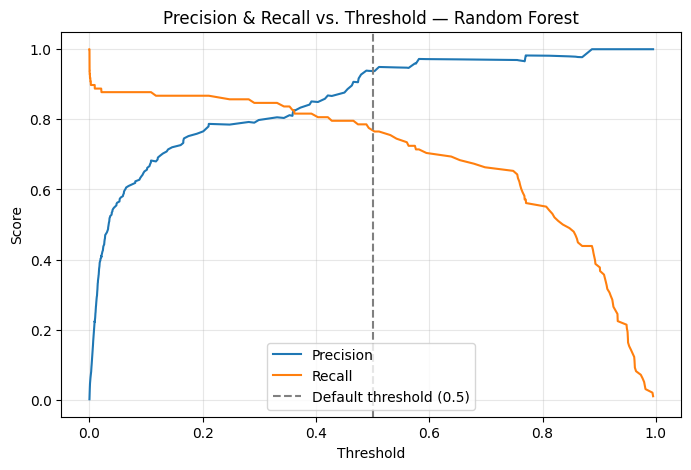

In [25]:
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_probs_rf)

plt.figure(figsize=(8,5))
plt.plot(pr_thresholds, precisions[:-1], label='Precision')
plt.plot(pr_thresholds, recalls[:-1], label='Recall')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.xlabel('Threshold'); plt.ylabel('Score')
plt.title('Precision & Recall vs. Threshold — Random Forest')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [26]:
# Validation-based threshold tuning for Random Forest, reusing the already-trained RF_classifier
val_probs_rf = RF_classifier.predict_proba(X_valid)[:, 1]

thresholds = [0.05, 0.08, 0.10, 0.12, 0.15, 0.18, 0.20, 0.25, 0.30, 0.40, 0.50, 0.6, 0.7]
results = []
for t in thresholds:
    y_pred_t = (val_probs_rf >= t).astype(int)
    results.append({
        "threshold": t,
        "precision": precision_score(y_valid, y_pred_t, zero_division=0),
        "recall": recall_score(y_valid, y_pred_t, zero_division=0),
        "f2": fbeta_score(y_valid, y_pred_t, beta=2, zero_division=0),
    })

rf_threshold_results = pd.DataFrame(results).sort_values("f2", ascending=False)
print(rf_threshold_results)

rf_best_threshold = float(rf_threshold_results.iloc[0]["threshold"])
print(f"\nBest validation threshold (Random Forest): {rf_best_threshold:.2f}")

# Evaluate once on the untouched test set, using probabilities from the same RF_classifier
y_probs_rf = RF_classifier.predict_proba(X_test)[:, 1]
y_pred_final = (y_probs_rf >= rf_best_threshold).astype(int)

print("\nRandom Forest test results with validation-selected threshold")
print(classification_report(y_test, y_pred_final, target_names=["Not Fraud", "Fraud"], zero_division=0))

f2_rf = fbeta_score(y_test, y_pred_final, beta=2, pos_label=1, zero_division=0)
print(f"F2-score (Fraud): {f2_rf:.4f}")

    threshold  precision    recall        f2
3        0.12   0.784314  0.808081  0.803213
5        0.18   0.814433  0.797980  0.801217
4        0.15   0.806122  0.797980  0.799595
2        0.10   0.754717  0.808081  0.796813
6        0.20   0.821053  0.787879  0.794297
1        0.08   0.727273  0.808081  0.790514
7        0.25   0.827957  0.777778  0.787321
0        0.05   0.666667  0.808081  0.775194
8        0.30   0.824176  0.757576  0.770021
9        0.40   0.837209  0.727273  0.746888
10       0.50   0.920000  0.696970  0.732484
11       0.60   0.942857  0.666667  0.708155
12       0.70   0.968254  0.616162  0.664488

Best validation threshold (Random Forest): 0.12

Random Forest test results with validation-selected threshold
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.69      0.87      0.77        98

    accuracy                           1.00     56962
   macro avg       0.84      0.93      0

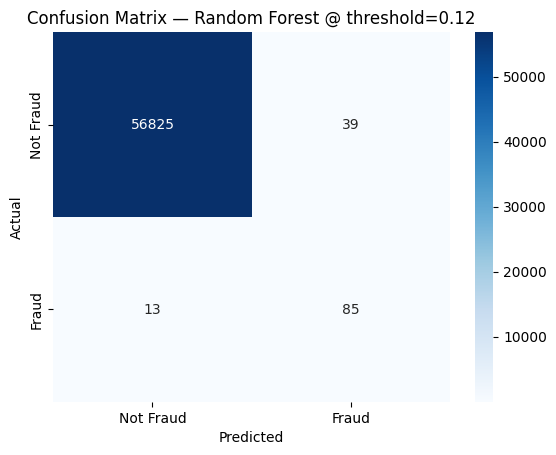

In [27]:
#Confusion Matrix — Random Forest, final chosen threshold
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Confusion Matrix — Random Forest @ threshold={rf_best_threshold:.2f}')
plt.show()

### Feature Importance

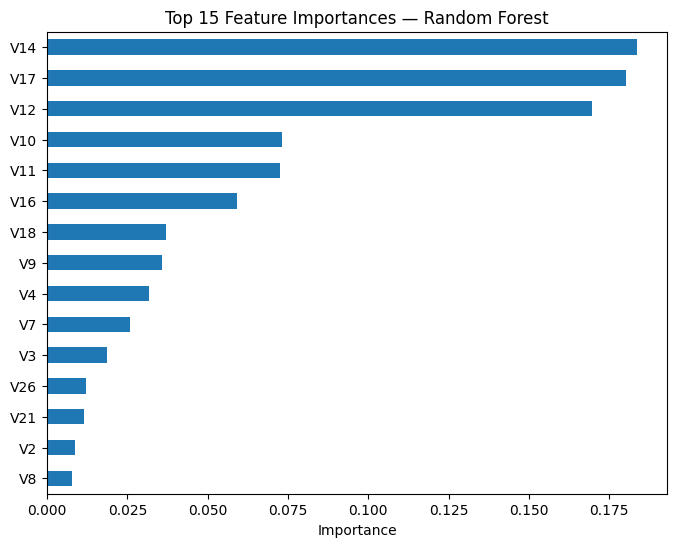

In [28]:
rf_model = RF_classifier.named_steps["model"]
importances = pd.Series(rf_model.feature_importances_, index=feature_names_after_preprocessing)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.show()

### SHAP

In [29]:
print(shap.__version__)

0.52.0


In [30]:
rf_model = RF_classifier.named_steps["model"]

X_test_processed = RF_classifier.named_steps["preprocessor"].transform(X_test)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test_processed)

In [31]:
print(type(shap_values))
print(shap_values.shape)

<class 'shap._explanation.Explanation'>
(56962, 30, 2)


In [32]:
fraud_shap = shap.Explanation(
    values=shap_values.values[:, :, 1],
    base_values=shap_values.base_values[:, 1],
    data=X_test_processed,
    feature_names=feature_names_after_preprocessing
)

In [33]:
shap.initjs()

shap.force_plot(
    base_value=fraud_shap.base_values[0],
    shap_values=fraud_shap.values[0],
    features=fraud_shap.data[0],
    feature_names=feature_names_after_preprocessing
)

### Decision Tree

Decision Tree on Train:
Accuracy: 0.9997

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    170588
       Fraud       0.91      0.92      0.92       295

    accuracy                           1.00    170883
   macro avg       0.96      0.96      0.96    170883
weighted avg       1.00      1.00      1.00    170883


Decision Tree on Test:
F2-score (Fraud): 0.7847
Accuracy: 0.9992

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.74      0.80      0.77        98

    accuracy                           1.00     56962
   macro avg       0.87      0.90      0.88     56962
weighted avg       1.00      1.00      1.00     56962



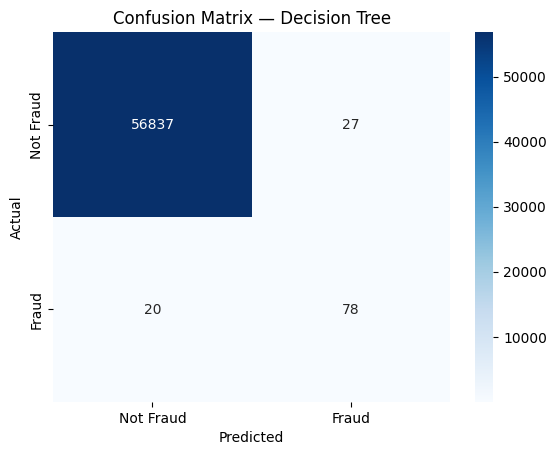

In [34]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(class_weight={0: 1, 1: 10}, criterion='gini', max_depth=10, random_state=42)),
])
dt_pipeline.fit(X_train, y_train)

y_train_pred_dt = dt_pipeline.predict(X_train)
print("Decision Tree on Train:")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred_dt):.4f}\n")
print(classification_report(y_train, y_train_pred_dt, target_names=['Not Fraud', 'Fraud'], zero_division=0))

y_preds_dt = dt_pipeline.predict(X_test)
print("\nDecision Tree on Test:")

f2_default = fbeta_score(y_test, y_preds_dt, beta=2, pos_label=1, zero_division=0)
print(f"F2-score (Fraud): {f2_default:.4f}")

print(f"Accuracy: {accuracy_score(y_test, y_preds_dt):.4f}\n")

print(classification_report(y_test, y_preds_dt, target_names=['Not Fraud', 'Fraud'], zero_division=0))

cm = confusion_matrix(y_test, y_preds_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix — Decision Tree')
plt.show()

### Find and Study the False Negatives

In [35]:
# Uses RF_classifier's final chosen threshold from the tuning step above
results_df = X_test.copy()
results_df['Actual'] = y_test.values
results_df['Predicted'] = y_pred_final
results_df['Fraud_Probability'] = y_probs_rf

false_negatives = results_df[(results_df['Actual'] == 1) & (results_df['Predicted'] == 0)]
true_positives = results_df[(results_df['Actual'] == 1) & (results_df['Predicted'] == 1)]

print(f"False Negatives: {len(false_negatives)}")
print(f"True Positives: {len(true_positives)}")

print("\nFalse Negatives — probability scores:")
print(false_negatives['Fraud_Probability'].describe())

False Negatives: 13
True Positives: 85

False Negatives — probability scores:
count    13.000000
mean      0.011160
std       0.029920
min       0.000108
25%       0.000167
50%       0.000346
75%       0.002382
max       0.108780
Name: Fraud_Probability, dtype: float64


In [36]:
feature_cols = [c for c in X_test.columns]

comparison = pd.DataFrame({
    'FN_mean': false_negatives[feature_cols].mean(),
    'TP_mean': true_positives[feature_cols].mean(),
})
comparison['abs_diff'] = (comparison['FN_mean'] - comparison['TP_mean']).abs()
comparison = comparison.sort_values('abs_diff', ascending=False)

print(comparison.head(10))

             FN_mean       TP_mean     abs_diff
Time    78550.230769  71416.447059  7133.783710
Amount    140.824615    103.696588    37.128027
V17         0.731105     -8.427501     9.158606
V3          0.009120     -7.947668     7.956788
V14        -0.793299     -8.179133     7.385834
V7          0.326892     -6.604012     6.930905
V10         0.042892     -6.503774     6.546666
V12        -0.817225     -7.264269     6.447044
V16         0.663341     -5.187578     5.850920
V1         -0.127206     -5.779632     5.652426


### Feed the Model More Examples Like the False Negatives (ADASYN)

In [37]:
adasyn = ADASYN(sampling_strategy=0.1, random_state=42, n_neighbors=5)
X_train_ada, y_train_ada = adasyn.fit_resample(X_train, y_train)

rf_ada = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)),
])
rf_ada.fit(X_train_ada, y_train_ada)

y_pred_ada = rf_ada.predict(X_test)

f2_default = fbeta_score(y_test, y_pred_ada, beta=2, pos_label=1, zero_division=0)
print(f"F2-score (Fraud): {f2_default:.4f}")

print(f"Accuracy: {accuracy_score(y_test, y_pred_ada):.4f}\n")

print(classification_report(y_test, y_pred_ada, target_names=['Not Fraud', 'Fraud'], zero_division=0))


F2-score (Fraud): 0.8417
Accuracy: 0.9994

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.79      0.86      0.82        98

    accuracy                           1.00     56962
   macro avg       0.89      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962



### KNN

Accuracy: 0.9994

F2-score (Fraud): 0.7733
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.91      0.74      0.82        98

    accuracy                           1.00     56962
   macro avg       0.96      0.87      0.91     56962
weighted avg       1.00      1.00      1.00     56962



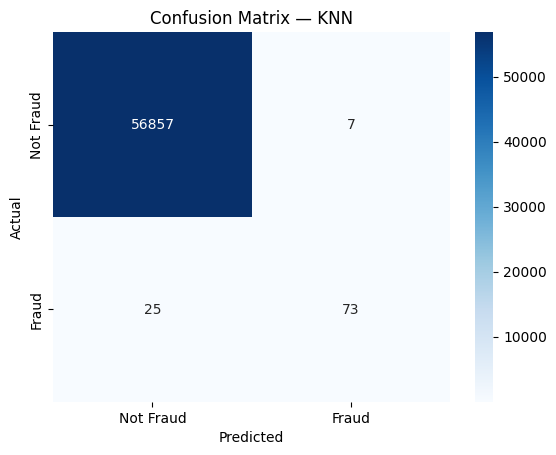

In [38]:
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
])
knn_pipeline.fit(X_train, y_train)

y_pred_knn = knn_pipeline.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}\n")

f2_default = fbeta_score(y_test, y_pred_knn, beta=2, pos_label=1, zero_division=0)
print(f"F2-score (Fraud): {f2_default:.4f}")

print(classification_report(y_test, y_pred_knn, target_names=['Not Fraud', 'Fraud'], zero_division=0))

cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix — KNN')
plt.show()

### Naive Bayes

Accuracy: 0.9762

F2-score (Fraud): 0.2287
              precision    recall  f1-score   support

   Not Fraud       1.00      0.98      0.99     56864
       Fraud       0.06      0.85      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.91      0.55     56962
weighted avg       1.00      0.98      0.99     56962



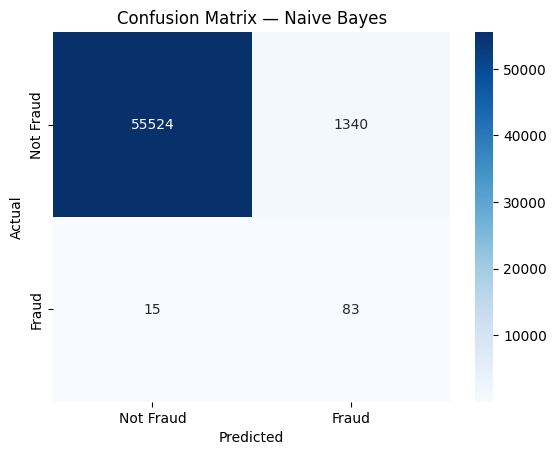

In [39]:
nb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GaussianNB()),
])
nb_pipeline.fit(X_train, y_train)

y_pred_nb = nb_pipeline.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}\n")

f2_default = fbeta_score(y_test, y_pred_nb, beta=2, pos_label=1, zero_division=0)
print(f"F2-score (Fraud): {f2_default:.4f}")

print(classification_report(y_test, y_pred_nb, target_names=['Not Fraud', 'Fraud'], zero_division=0))

cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix — Naive Bayes')
plt.show()

## Model Comparison & Evaluation

**Note:** the table below needs to be filled in with real numbers after running this notebook
top to bottom — all placeholder values from before the Pipeline rewrite have been removed,
since preprocessing has changed (RobustScaler instead of StandardScaler, no Hour/Amount_log
features) and results will differ from earlier runs. Copy the printed classification report
values from each model's cell above into this table once you've rerun the notebook.

| Model | Accuracy | Precision (Fraud) | Recall (Fraud) | F1 (Fraud) | F2 (Fraud) |
|---|---|---|---|---|---|
| XGBoost (default threshold) | 0.998 | 0.64 | 0.86 | 0.73 | 0.8031 |
| XGBoost (validation-tuned threshold = 0.90) | 0.9994 | 0.85 | 0.83 | 0.84 | 0.83 |
| Random Forest (default threshold) | 0.9995 | 0.92 | 0.81 | 0.86 | 0.8264 |
| Random Forest (SMOTE) | 0.9994 | 0.83 | 0.82 | 0.82 | 0.8197 |
| Random Forest (undersampled) | 0.9726 | 0.05 | 0.92 | 0.10 | 0.22 |
| Random Forest (ADASYN) | 0.9993 | 0.74 | 0.88 | 0.80 | 0.8465 |
| **Random Forest (validation-tuned threshold = 0.12)** | 1 | **0.69** | **0.88** | **0.77** | **0.83** |
| Logistic Regression + class weight | 0.998 | 0.53 | 0.88 | 0.66 | - |
| Decision Tree | 0.9993 | 0.79 | 0.78 | 0.78 | 0.7787 |
| KNN | 0.9995 | 0.92 | 0.79 | 0.85 | 0.8088 |
| Naive Bayes | 0.9764 | 0.06 | 0.85 | 0.11 | 0.2300 |

In [40]:
#Map each fitted pipeline (or final prediction arrays) to a name
models_to_compare = {
    "Logistic Regression": (log_reg_pipeline, log_reg_pipeline.predict(X_test)),
    "Decision Tree": (dt_pipeline, dt_pipeline.predict(X_test)),
    "KNN": (knn_pipeline, knn_pipeline.predict(X_test)),
    "Naive Bayes": (nb_pipeline, nb_pipeline.predict(X_test)),
    "XGBoost (tuned threshold)": (None, xgb_test_pred),          # already computed earlier with a custom threshold
    "Random Forest (tuned threshold)": (None, y_pred_final),      # already computed earlier with threshold=0.12
}

rows = []
for name, (pipeline, y_pred) in models_to_compare.items():
    rows.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "F2": fbeta_score(y_test, y_pred, beta=2, zero_division=0),
    })

comparison_df = pd.DataFrame(rows)
print(comparison_df)

                             Model  Precision    Recall        F1        F2
0              Logistic Regression   0.530864  0.877551  0.661538  0.776173
1                    Decision Tree   0.742857  0.795918  0.768473  0.784708
2                              KNN   0.912500  0.744898  0.820225  0.773305
3                      Naive Bayes   0.058327  0.846939  0.109139  0.228650
4        XGBoost (tuned threshold)   0.838384  0.846939  0.842640  0.845214
5  Random Forest (tuned threshold)   0.685484  0.867347  0.765766  0.823643


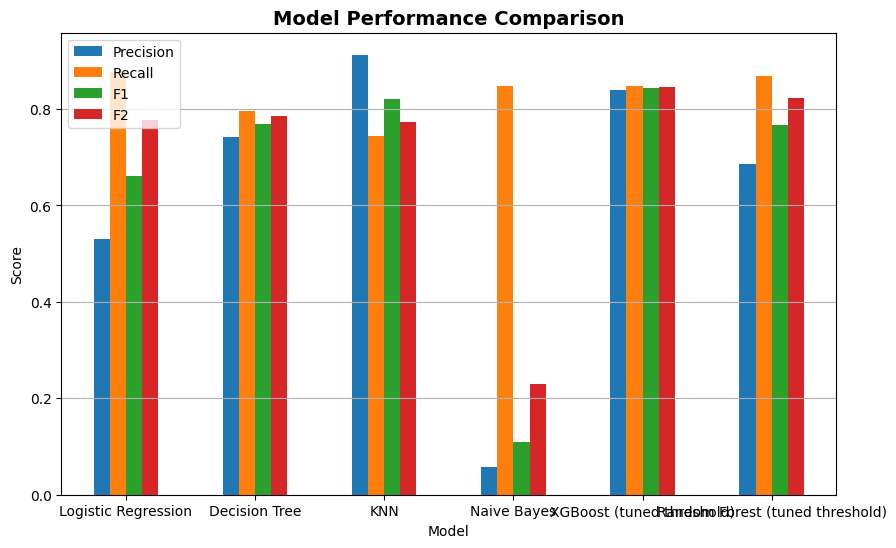

In [41]:
comparison_plot = comparison_df.set_index("Model")

comparison_plot.plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

### Save Model for Streamlit

In [42]:
# The entire pipeline (preprocessing + model) is saved as a single file.
# This means app.py only needs to load ONE file and call .predict_proba() directly
# on raw input columns (Time, Amount, V1-V28) — no manual scaling or feature engineering
# needs to be replicated in the app.

joblib.dump(RF_classifier, 'fraud_model.pkl')
print("Model pipeline saved to fraud_model.pkl")

Model pipeline saved to fraud_model.pkl
